# 06 — Uplift Modeling with T-Learner

## Objective

This notebook introduces individual treatment-effect estimation using a T-Learner approach.

Unlike conventional predictive modeling, uplift modeling estimates how the treatment changes the expected outcome for individual customers.

The T-Learner uses two separate outcome models:

- Treatment model: estimates conversion probability under treatment
- Control model: estimates conversion probability under control

Individual uplift is then calculated as:

    Uplift = P(Y=1 | X, Treatment=1)
             -
             P(Y=1 | X, Treatment=0)

The resulting uplift score represents the estimated incremental effect of treatment for each customer.

### Business Objective

The goal is not simply to identify customers most likely to convert.

The goal is to identify customers whose conversion probability is expected to increase because of treatment.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [15]:
DATA_PATH = Path(
    r"C:\Users\ugand\customer-churn-uplift-modeling\data\raw\criteo-research-uplift-v2.1.csv.gz"
)

print("Dataset exists:", DATA_PATH.exists())

if DATA_PATH.exists():
    print(
        "Dataset size (MB):",
        round(DATA_PATH.stat().st_size / (1024 ** 2), 2)
    )

Dataset exists: True
Dataset size (MB): 297.0


In [16]:
SAMPLE_SIZE = 100_000
CHUNK_SIZE = 250_000
RANDOM_STATE = 42

rng = np.random.default_rng(RANDOM_STATE)

sample_parts = []

rows_per_chunk = 10_000

for chunk in pd.read_csv(
    DATA_PATH,
    compression="gzip",
    chunksize=CHUNK_SIZE
):
    
    sample_size = min(
        rows_per_chunk,
        len(chunk)
    )
    
    sampled_chunk = chunk.sample(
        n=sample_size,
        random_state=RANDOM_STATE
    )
    
    sample_parts.append(sampled_chunk)

df = pd.concat(
    sample_parts,
    ignore_index=True
)

if len(df) > SAMPLE_SIZE:
    df = df.sample(
        n=SAMPLE_SIZE,
        random_state=RANDOM_STATE
    ).reset_index(drop=True)

print("Sample shape:", df.shape)

Sample shape: (100000, 16)


In [17]:
print("Columns:")
print(df.columns.tolist())

print("\nNumber of columns:", len(df.columns))

Columns:
['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'treatment', 'conversion', 'visit', 'exposure']

Number of columns: 16


In [18]:
feature_cols = [
    f"f{i}"
    for i in range(12)
]

treatment_col = "treatment"
outcome_col = "conversion"

X = df[feature_cols].copy()

treatment = df[treatment_col].copy()

y = df[outcome_col].copy()

print("Feature shape:", X.shape)
print("Treatment shape:", treatment.shape)
print("Outcome shape:", y.shape)

Feature shape: (100000, 12)
Treatment shape: (100000,)
Outcome shape: (100000,)


In [19]:
treatment_counts = treatment.value_counts(
    dropna=False
).sort_index()

print(treatment_counts)

print("\nUnique treatment values:")
print(sorted(treatment.dropna().unique()))

treatment
0    15066
1    84934
Name: count, dtype: int64

Unique treatment values:
[np.int64(0), np.int64(1)]


In [20]:
treatment_proportions = (
    treatment
    .value_counts(normalize=True)
    .sort_index()
)

print(treatment_proportions)

treatment
0    0.15066
1    0.84934
Name: proportion, dtype: float64


In [21]:
print("Conversion counts:")
print(y.value_counts().sort_index())

print("\nConversion rate:")
print(y.mean())

Conversion counts:
conversion
0    99656
1      344
Name: count, dtype: int64

Conversion rate:
0.00344


In [22]:
group_conversion = (
    df.groupby("treatment")["conversion"]
      .agg(
          customers="count",
          conversions="sum",
          conversion_rate="mean"
      )
)

group_conversion

,customers,conversions,conversion_rate
treatment,,,
0,15066,31,0.002058
1,84934,313,0.003685


In [23]:
control_rate = df.loc[
    df["treatment"] == 0,
    "conversion"
].mean()

treatment_rate = df.loc[
    df["treatment"] == 1,
    "conversion"
].mean()

observed_effect = (
    treatment_rate -
    control_rate
)

print(
    f"Control conversion rate:   {control_rate:.6f}"
)

print(
    f"Treatment conversion rate: {treatment_rate:.6f}"
)

print(
    f"Observed treatment effect: {observed_effect:.6f}"
)

Control conversion rate:   0.002058
Treatment conversion rate: 0.003685
Observed treatment effect: 0.001628


In [24]:
X_train, X_test, y_train, y_test, treatment_train, treatment_test = train_test_split(
    X,
    y,
    treatment,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print(
    "\nTraining treatment distribution:"
)

print(
    treatment_train.value_counts()
)

print(
    "\nTesting treatment distribution:"
)

print(
    treatment_test.value_counts()
)

Training rows: 80000
Testing rows: 20000

Training treatment distribution:
treatment
1    67971
0    12029
Name: count, dtype: int64

Testing treatment distribution:
treatment
1    16963
0     3037
Name: count, dtype: int64


In [25]:
control_mask = (
    treatment_train == 0
)

X_control = X_train.loc[
    control_mask
].copy()

y_control = y_train.loc[
    control_mask
].copy()

print("Control X shape:", X_control.shape)
print("Control y shape:", y_control.shape)

print(
    "\nControl conversion rate:",
    y_control.mean()
)

Control X shape: (12029, 12)
Control y shape: (12029,)

Control conversion rate: 0.002078310749023194


In [26]:
treatment_mask = (
    treatment_train == 1
)

X_treatment = X_train.loc[
    treatment_mask
].copy()

y_treatment = y_train.loc[
    treatment_mask
].copy()

print(
    "Treatment X shape:",
    X_treatment.shape
)

print(
    "Treatment y shape:",
    y_treatment.shape
)

print(
    "\nTreatment conversion rate:",
    y_treatment.mean()
)

Treatment X shape: (67971, 12)
Treatment y shape: (67971,)

Treatment conversion rate: 0.0036780391637610157


In [27]:
print("Control observations:", len(X_control))
print("Treatment observations:", len(X_treatment))

print(
    "\nControl outcome classes:",
    sorted(y_control.unique())
)

print(
    "Treatment outcome classes:",
    sorted(y_treatment.unique())
)

Control observations: 12029
Treatment observations: 67971

Control outcome classes: [np.int64(0), np.int64(1)]
Treatment outcome classes: [np.int64(0), np.int64(1)]


In [28]:
control_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

control_model.fit(
    X_control,
    y_control
)

print("Control model trained successfully.")

Control model trained successfully.


In [29]:
treatment_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

treatment_model.fit(
    X_treatment,
    y_treatment
)

print("Treatment model trained successfully.")

Treatment model trained successfully.


In [30]:
mu_control = control_model.predict_proba(
    X_test
)[:, 1]

print(
    "Control predictions generated:",
    len(mu_control)
)

print(
    "Prediction range:",
    mu_control.min(),
    "to",
    mu_control.max()
)

Control predictions generated: 20000
Prediction range: 0.0 to 0.9438663957815112


In [31]:
mu_treatment = treatment_model.predict_proba(
    X_test
)[:, 1]

print(
    "Treatment predictions generated:",
    len(mu_treatment)
)

print(
    "Prediction range:",
    mu_treatment.min(),
    "to",
    mu_treatment.max()
)

Treatment predictions generated: 20000
Prediction range: 0.0005473980653640038 to 0.994655355864754


In [32]:
uplift = (
    mu_treatment -
    mu_control
)

uplift_df = pd.DataFrame({
    "customer_index": X_test.index,
    "actual_treatment": treatment_test.values,
    "actual_conversion": y_test.values,
    "predicted_control": mu_control,
    "predicted_treatment": mu_treatment,
    "uplift": uplift
})

uplift_df.head()

,customer_index,actual_treatment,actual_conversion,predicted_control,predicted_treatment,uplift
0,21175,1,0,0.000436,0.014119,0.013683
1,28968,1,0,0.054692,0.095128,0.040436
2,78207,0,0,0.276301,0.032204,-0.244096
3,25183,1,0,0.000686,0.002107,0.001421
4,97744,0,0,0.000000,0.020826,0.020826


In [33]:
uplift_df["uplift"].describe()

count    20000.000000
mean         0.041975
std          0.079734
min         -0.381696
25%          0.001421
50%          0.010399
75%          0.054337
max          0.747002
Name: uplift, dtype: float64

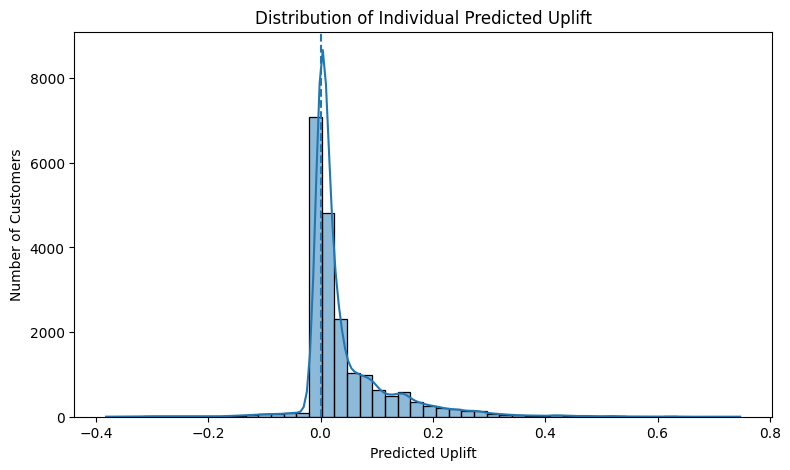

In [34]:
plt.figure(figsize=(9, 5))

sns.histplot(
    uplift_df["uplift"],
    bins=50,
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "Distribution of Individual Predicted Uplift"
)

plt.xlabel(
    "Predicted Uplift"
)

plt.ylabel(
    "Number of Customers"
)

plt.show()

In [35]:
UPLIFT_THRESHOLD = 0.001

uplift_df["uplift_segment"] = np.select(
    [
        uplift_df["uplift"] > UPLIFT_THRESHOLD,
        uplift_df["uplift"] < -UPLIFT_THRESHOLD
    ],
    [
        "Positive Uplift",
        "Negative Uplift"
    ],
    default="Neutral Uplift"
)

uplift_df["uplift_segment"].value_counts()

uplift_segment
Positive Uplift    16915
Neutral Uplift      2403
Negative Uplift      682
Name: count, dtype: int64

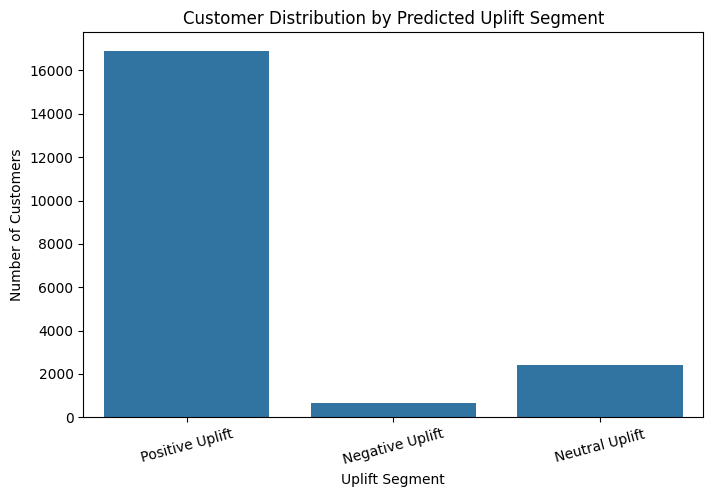

In [36]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=uplift_df,
    x="uplift_segment"
)

plt.title(
    "Customer Distribution by Predicted Uplift Segment"
)

plt.xlabel(
    "Uplift Segment"
)

plt.ylabel(
    "Number of Customers"
)

plt.xticks(rotation=15)

plt.show()

In [37]:
uplift_ranked = (
    uplift_df
    .sort_values(
        "uplift",
        ascending=False
    )
    .reset_index(drop=True)
)

uplift_ranked.head(20)

,customer_index,actual_treatment,actual_conversion,predicted_control,predicted_treatment,uplift,uplift_segment
0,99343,1,0,0.123074,0.870076,0.747002,Positive Uplift
1,74161,0,0,0.113354,0.811204,0.697850,Positive Uplift
2,58759,1,0,0.052978,0.688561,0.635583,Positive Uplift
3,96475,1,0,0.083911,0.713814,0.629903,Positive Uplift
4,68151,1,0,0.123849,0.753358,0.629509,Positive Uplift
5,31892,1,0,0.078600,0.703329,0.624729,Positive Uplift
6,86056,1,0,0.075880,0.700358,0.624478,Positive Uplift
7,58131,1,0,0.187960,0.809818,0.621858,Positive Uplift
8,66408,1,0,0.162315,0.777227,0.614912,Positive Uplift
9,11654,0,0,0.055588,0.649322,0.593734,Positive Uplift


In [38]:
top10_cutoff = (
    uplift_df["uplift"]
    .quantile(0.90)
)

top10 = uplift_df[
    uplift_df["uplift"] >= top10_cutoff
].copy()

print(
    "Top 10% uplift cutoff:",
    top10_cutoff
)

print(
    "Customers in top 10%:",
    len(top10)
)

print(
    "Mean uplift in top 10%:",
    top10["uplift"].mean()
)

Top 10% uplift cutoff: 0.1447797191146267
Customers in top 10%: 2000
Mean uplift in top 10%: 0.23143846080689995


In [39]:
top20_cutoff = (
    uplift_df["uplift"]
    .quantile(0.80)
)

top20 = uplift_df[
    uplift_df["uplift"] >= top20_cutoff
].copy()

print(
    "Top 20% uplift cutoff:",
    top20_cutoff
)

print(
    "Customers in top 20%:",
    len(top20)
)

print(
    "Mean uplift in top 20%:",
    top20["uplift"].mean()
)

Top 20% uplift cutoff: 0.07602968790966363
Customers in top 20%: 4001
Mean uplift in top 20%: 0.16853295045752723


In [40]:
uplift_df["uplift_decile"] = pd.qcut(
    uplift_df["uplift"],
    q=10,
    labels=False,
    duplicates="drop"
) + 1

decile_summary = (
    uplift_df
    .groupby("uplift_decile")
    .agg(
        customers=("uplift", "size"),
        mean_uplift=("uplift", "mean"),
        mean_predicted_treatment=(
            "predicted_treatment",
            "mean"
        ),
        mean_predicted_control=(
            "predicted_control",
            "mean"
        )
    )
    .sort_index(ascending=False)
)

decile_summary

,customers,mean_uplift,mean_predicted_treatment,mean_predicted_control
uplift_decile,,,,
10,2000,0.231438,0.316885,0.085447
9,1999,0.105689,0.157952,0.052263
8,2001,0.054547,0.089394,0.034847
7,1999,0.028270,0.039464,0.011194
6,2001,0.014821,0.024371,0.009551
5,1692,0.005861,0.014105,0.008244
4,1616,0.001939,0.003398,0.001459
3,2441,0.001406,0.001984,0.000578
2,1672,0.001069,0.002360,0.001291


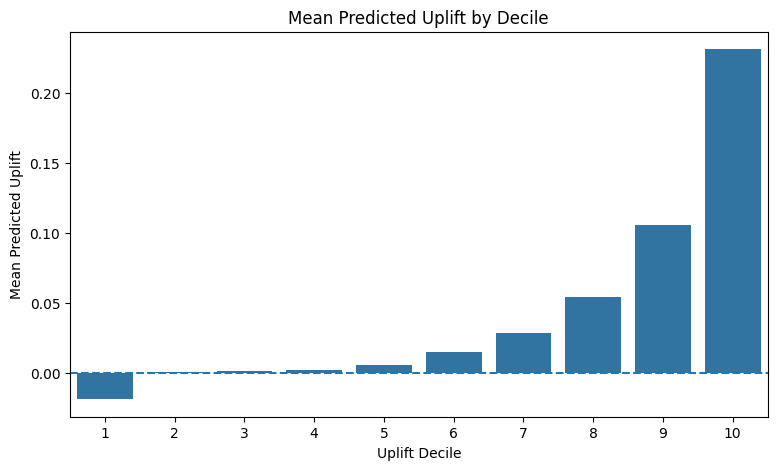

In [41]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=decile_summary.reset_index(),
    x="uplift_decile",
    y="mean_uplift"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "Mean Predicted Uplift by Decile"
)

plt.xlabel(
    "Uplift Decile"
)

plt.ylabel(
    "Mean Predicted Uplift"
)

plt.show()

In [42]:
control_test_mask = (
    treatment_test == 0
)

treatment_test_mask = (
    treatment_test == 1
)

control_auc = roc_auc_score(
    y_test[control_test_mask],
    mu_control[control_test_mask]
)

treatment_auc = roc_auc_score(
    y_test[treatment_test_mask],
    mu_treatment[treatment_test_mask]
)

print(
    f"Control model ROC-AUC:   {control_auc:.4f}"
)

print(
    f"Treatment model ROC-AUC: {treatment_auc:.4f}"
)

Control model ROC-AUC:   0.9524
Treatment model ROC-AUC: 0.9621


In [43]:
control_pr_auc = average_precision_score(
    y_test[control_test_mask],
    mu_control[control_test_mask]
)

treatment_pr_auc = average_precision_score(
    y_test[treatment_test_mask],
    mu_treatment[treatment_test_mask]
)

print(
    f"Control model PR-AUC:   {control_pr_auc:.4f}"
)

print(
    f"Treatment model PR-AUC: {treatment_pr_auc:.4f}"
)

Control model PR-AUC:   0.1145
Treatment model PR-AUC: 0.2475


In [44]:
model_performance = pd.DataFrame({
    "model": [
        "Control Outcome Model",
        "Treatment Outcome Model"
    ],
    "ROC_AUC": [
        control_auc,
        treatment_auc
    ],
    "PR_AUC": [
        control_pr_auc,
        treatment_pr_auc
    ]
})

model_performance

,model,ROC_AUC,PR_AUC
0,Control Outcome Model,0.952436,0.114474
1,Treatment Outcome Model,0.962069,0.247450


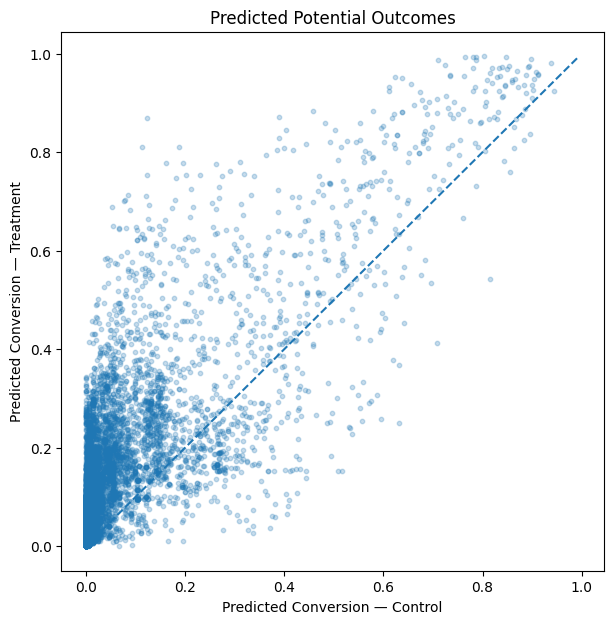

In [45]:
plt.figure(figsize=(7, 7))

plt.scatter(
    uplift_df["predicted_control"],
    uplift_df["predicted_treatment"],
    alpha=0.25,
    s=10
)

max_value = max(
    uplift_df["predicted_control"].max(),
    uplift_df["predicted_treatment"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)

plt.xlabel(
    "Predicted Conversion — Control"
)

plt.ylabel(
    "Predicted Conversion — Treatment"
)

plt.title(
    "Predicted Potential Outcomes"
)

plt.show()

In [46]:
comparison = pd.DataFrame({
    "segment": [
        "All Customers",
        "Top 20% Uplift"
    ],
    "customers": [
        len(uplift_df),
        len(top20)
    ],
    "mean_uplift": [
        uplift_df["uplift"].mean(),
        top20["uplift"].mean()
    ],
    "mean_predicted_treatment": [
        uplift_df["predicted_treatment"].mean(),
        top20["predicted_treatment"].mean()
    ],
    "mean_predicted_control": [
        uplift_df["predicted_control"].mean(),
        top20["predicted_control"].mean()
    ]
})

comparison

,segment,customers,mean_uplift,mean_predicted_treatment,mean_predicted_control
0,All Customers,20000,0.041975,0.070286,0.028311
1,Top 20% Uplift,4001,0.168533,0.237361,0.068828


In [47]:
OUTPUT_DIR = Path(
    r"C:\Users\ugand\customer-churn-uplift-modeling\data\processed"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

uplift_output_path = (
    OUTPUT_DIR /
    "t_learner_uplift_predictions.csv"
)

uplift_df.to_csv(
    uplift_output_path,
    index=False
)

print(
    "Uplift predictions saved to:"
)

print(
    uplift_output_path
)

Uplift predictions saved to:
C:\Users\ugand\customer-churn-uplift-modeling\data\processed\t_learner_uplift_predictions.csv


In [48]:
performance_output_path = (
    OUTPUT_DIR /
    "t_learner_model_performance.csv"
)

model_performance.to_csv(
    performance_output_path,
    index=False
)

print(
    "Model performance saved to:"
)

print(
    performance_output_path
)

Model performance saved to:
C:\Users\ugand\customer-churn-uplift-modeling\data\processed\t_learner_model_performance.csv


In [49]:
final_summary = pd.DataFrame({
    "metric": [
        "Test observations",
        "Control observations",
        "Treatment observations",
        "Control conversion rate",
        "Treatment conversion rate",
        "Observed treatment effect",
        "Mean predicted uplift",
        "Median predicted uplift",
        "Positive uplift customers",
        "Negative uplift customers",
        "Top 20% mean uplift"
    ],
    "value": [
        len(uplift_df),
        int((treatment_test == 0).sum()),
        int((treatment_test == 1).sum()),
        control_rate,
        treatment_rate,
        observed_effect,
        uplift_df["uplift"].mean(),
        uplift_df["uplift"].median(),
        int((uplift_df["uplift"] > 0).sum()),
        int((uplift_df["uplift"] < 0).sum()),
        top20["uplift"].mean()
    ]
})

final_summary

,metric,value
0,Test observations,20000.000000
1,Control observations,3037.000000
2,Treatment observations,16963.000000
3,Control conversion rate,0.002058
4,Treatment conversion rate,0.003685
5,Observed treatment effect,0.001628
6,Mean predicted uplift,0.041975
7,Median predicted uplift,0.010399
8,Positive uplift customers,19309.000000
9,Negative uplift customers,691.000000


# Conclusion

## T-Learner Uplift Modeling Summary

This notebook implemented a T-Learner framework for estimating individual treatment effects.

Two separate Random Forest models were trained:

- A Control Outcome Model estimating conversion probability under control
- A Treatment Outcome Model estimating conversion probability under treatment

The difference between the two predicted potential outcomes was used to calculate an individual uplift score.

### Key Findings

- The dataset was separated into treatment and control groups before model training.
- Separate outcome models were successfully trained for the two treatment conditions.
- Individual treatment-effect estimates were generated for the test population.
- Customers displayed heterogeneous predicted treatment responses.
- Some customers received positive predicted uplift scores, while others received neutral or negative scores.
- Customers can be ranked according to predicted incremental treatment benefit.
- Uplift deciles provide a useful foundation for evaluating targeted treatment strategies.

### Business Interpretation

Traditional predictive modeling asks:

> Who is most likely to convert?

Uplift modeling asks:

> Who is most likely to convert because of the treatment?

This distinction is important for marketing optimization.

A customer with a high probability of conversion under both treatment and control may not provide much incremental value from treatment.

In contrast, a customer with a relatively low control probability but substantially higher treatment probability may represent a strong treatment target.

### Limitations

The T-Learner is a baseline individual treatment-effect approach.

Its performance depends on the quality of the separate treatment and control outcome models.

The current notebook also uses a randomized development sample rather than training on the entire Criteo dataset.

Therefore, the individual uplift estimates should be interpreted as model-based estimates rather than directly observed individual causal effects.

### Next Step

The next notebook will evaluate the quality of the uplift ranking using dedicated uplift-modeling metrics.

These will include:

- Qini Curve
- Qini Coefficient
- AUUC
- Uplift@10%
- Uplift@20%
- Cumulative Gain
- Treatment Targeting Curves

This evaluation will determine whether the T-Learner successfully identifies customers who are most likely to benefit incrementally from treatment.